# 1. 기본 모듈 import & 데이터 로드

In [2]:
from sklearn.datasets import load_iris           #dataset load
from sklearn.tree import DecisionTreeClassifier  #머신러닝 모델(알고리즘) - 결정트리
from sklearn.metrics import accuracy_score       #성능 평가  
import pandas as pd
import numpy as np                               #k개 성능을 평균내기 위해서 np.mean()사용

In [3]:
iris = pd.read_csv('iris.csv')
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
X=iris.drop('target', axis=1)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [6]:
y=iris['target']
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

# 2. 교차 검증
- 고정된 학습 데이터와  검증 데이터를 사용할 경우 과적합(Overfitting)을 유발할 수 있음

- 과적합이란, 모델이 학습 데이터에만 과도하게 최적화되어 실제 예측을 다른 데이터로 수행시 예측성능이 떨어지는 것!

- 이 문제를 해결하기 위하여 교차검증 기법을 사용함

## 1) K-폴드 교차검증 (K-fold Cross Validation)이란?

- 가장 보편적으로 사용하는 교차 검증 기법

- K개의 데이터 폴드 세트를 구성, K번 만큼 각 폴드 세트에서 학습과 검증을 반복적으로 수행

- 예를 들어, 4번을 반복수행 했다면,이를 평균하여 평가 결과로 사용함

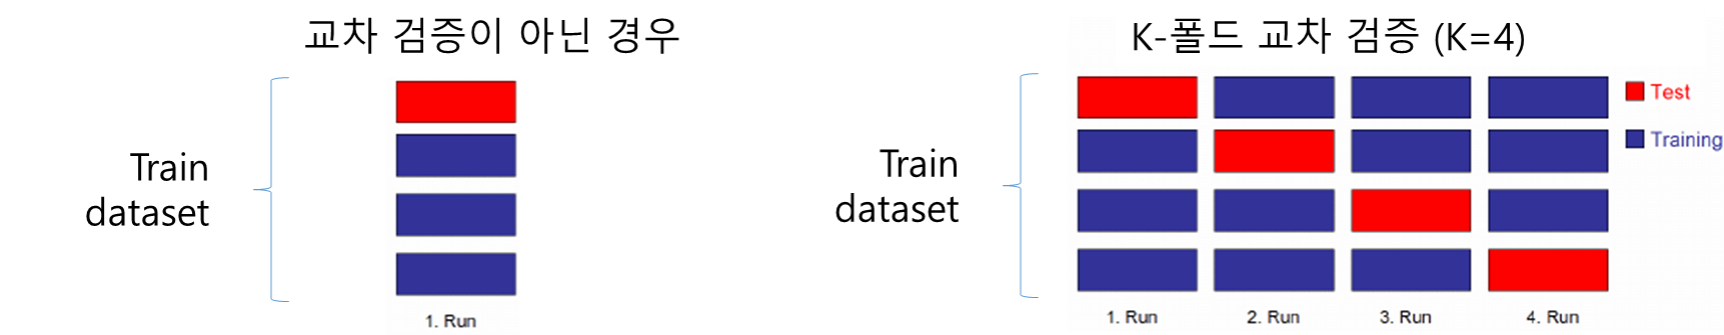

## 2) cross_val_score() 함수로 K-폴드 교차 검증 수행

In [3]:
# cross validation을 위한 사이킷런 모듈 import
from sklearn.model_selection import cross_val_score

In [4]:
# estimator 생성
dtree = DecisionTreeClassifier(random_state=0)

### cross_val_score(estimator, X,  y,  scoring, CV)
- 교차검증 수행을 편리하게 해주는 함수 
- estimator: 선택한 알고리즘(분류(classfier)인지 회귀(Regressor)인지)
- X: feature 데이터
- y: label 데이터
- scoring: 예측성능 평가방법 
- CV: 교차검증 폴더수 (CV=4, 총 4개의 결과가 return)

In [5]:
scores = cross_val_score(dtree, X,  y, scoring='accuracy',cv=4)
scores

array([0.97368421, 0.94736842, 0.94594595, 1.        ])

In [6]:
# 평균값
round(np.mean(scores), 4)

0.9667

- 검증용 셋(Fold 1)을 변경해가며 predict하고 평가하는 과정을 함수 내부에서 반복
- 따라서, 별도로 검증용셋을 확보하거나 (train_test_split()), 
- 검증용셋을 대상으로 예측하여 평가 (predict, accuracy계산) 해 볼 필요가 없음